In [ ]:
# Real-time image detection with webcam/video
import torch
import numpy as np
import cv2

model = torch.hub.load('ultralytics/yolov5', 'yolov5s')

cap = cv2.VideoCapture('car-traffic.mp4')

# Create a resizable window so large frames are not cropped on screen.
cv2.namedWindow('YOLO', cv2.WINDOW_NORMAL)

max_display_w = 960
max_display_h = 720

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Image detection on original frame
    results = model(frame)
    rendered = np.squeeze(results.render())

    # Resize for display only (keeps aspect ratio)
    h, w = rendered.shape[:2]
    scale = min(max_display_w / w, max_display_h / h, 1.0)
    display_frame = cv2.resize(
        rendered,
        (int(w * scale), int(h * scale)),
        interpolation=cv2.INTER_AREA,
    )

    cv2.imshow('YOLO', display_frame)
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


In [1]:
import sys 
print(sys.version)

3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]


In [4]:
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [5]:
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...


In [6]:
!cd yolov5 & pip install -r requirements.txt

  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached thop-0.1.1.post2209072238-py3-none-any.whl.metadata (2.7 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached ultralytics-8.4.41-py3-none-any.whl.metadata (39 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached ultralytics_thop-2.0.18-py3-none-any.whl.metadata (14 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached gitpython-3.1.46-py3-none-any.whl (208 kB)


In [3]:
import torch
from matplotlib import pyplot as plt
import numpy as np
import cv2

In [ ]:
model = torch.hub.load('ultralytics/yolov5', 'yolov5s')

Using cache found in C:\Users\ekram/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2026-4-21 Python-3.14.4 torch-2.11.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [6]:
model

AutoShape(
  (model): DetectMultiBackend(
    (model): DetectionModel(
      (model): Sequential(
        (0): Conv(
          (conv): Conv2d(3, 32, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2))
          (act): SiLU(inplace=True)
        )
        (1): Conv(
          (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (act): SiLU(inplace=True)
        )
        (2): C3(
          (cv1): Conv(
            (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv2): Conv(
            (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv3): Conv(
            (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
            (act): SiLU(inplace=True)
          )
          (m): Sequential(
            (0): Bottleneck(
              (cv1): Conv(
                (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  

In [23]:
zidane_img = "https://ultralytics.com/images/zidane.jpg" 
img = 'https://grist.org/wp-content/uploads/2011/02/china-beijing-cars-500-flickr-remko-tanis1.jpg'

C:\Users\ekram/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 333x500 30 cars, 2 buss, 2 trucks
Speed: 571.5ms pre-process, 243.2ms inference, 5.1ms NMS per image at shape (1, 3, 448, 640)


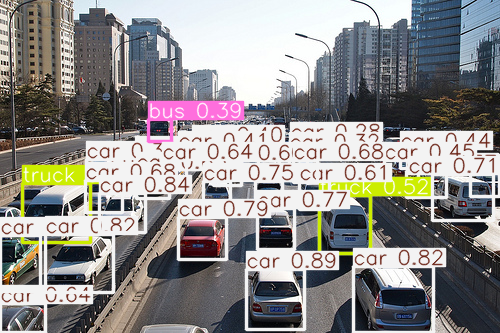

Saved 1 image to runs\detect\exp3


In [24]:
results = model(img)

# Process the results (options: .print(), .show(), .save(), .crop(), .pandas())
results.print()  # Print results to console
results.show()  # Display results in a window
results.save()  # Save results to runs/detect/exp

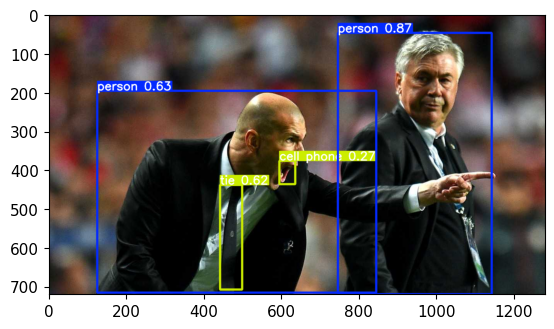

In [21]:
%matplotlib inline
plt.imshow(np.squeeze(results.render()))
plt.show()


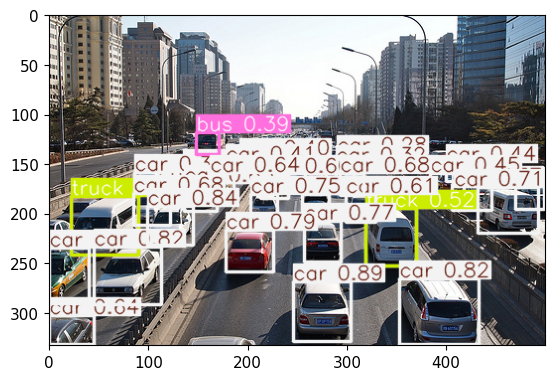

In [25]:
%matplotlib inline
plt.imshow(np.squeeze(results.render()))

In [ ]:
# Real-time iamge detection with webcam
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # image detection
    results = model(frame)

    # display results
    cv2.imshow('YOLO', np.squeeze(results.render()))
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()



In [8]:
# Real-time detection with video
cap = cv2.VideoCapture("car-traffic-02.mp4")

# Resizable preview window
cv2.namedWindow("YOLO", cv2.WINDOW_NORMAL)
# Smaller preview size -> appears zoomed out
max_display_w = 640
max_display_h = 360

while cap.isOpened():
  ret, frame = cap.read()
  if not ret:
      break

  # Detection on original frame
  results = model(frame)
  rendered = np.squeeze(results.render())

  # Resize only for display (keep aspect ratio)
  h, w = rendered.shape[:2]
  scale = min(max_display_w / w, max_display_h / h, 1.0)
  display_frame = cv2.resize(
      rendered,
      (int(w * scale), int(h * scale)),
      interpolation=cv2.INTER_AREA
  )
  cv2.imshow("YOLO", display_frame)
  if cv2.waitKey(10) & 0xFF == ord("q"):
      break

cap.release()
cv2.destroyAllWindows()



C:\Users\ekram/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\ekram/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\ekram/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\ekram/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\ekram/.cache\torch\hub\ultralytics_yolov5_master\models

KeyboardInterrupt: 

In [9]:
import uuid
import os
import time

In [13]:
# drowsiness

# Real-time iamge detection with webcam
IMAGES_PATH = os.path.join('data', 'images') # /data/imgs
labels = [ 'awake', 'drowsy']
number_imgs = 20

cap = cv2.VideoCapture(0)
for label in labels:
    print('Collecting images for {}'.format(label))
    time.sleep(5)


In [25]:
# drowsiness

# Real-time iamge detection with webcam
IMAGES_PATH = os.path.join('data', 'images') # /data/imgs
labels = [ 'awake', 'drowsy']
number_imgs = 20

cap = cv2.VideoCapture(0)
for label in labels:
    print('Collecting images for {}'.format(label))
    time.sleep(5)

    for img_num in range(number_imgs):
        print('Collecting images for {}, image number {}'.format(label, img_num))

        ret, frame = cap.read()

        imgname = os.path.join(IMAGES_PATH, label + '.' + str(uuid.uuid1()) + '.jpg')
        cv2.imwrite(imgname, frame)
        cv2.imshow('Image collection', frame)
        time.sleep(2)

        if cv2.waitKey(10) & 0xFF == ord("q"):
            break

cap.release()
cv2.destroyAllWindows()



In [ ]:
IMAGES_PATH = os.path.join('data', 'images') # /data/imgs
labels = [ 'awake', 'drowsy']
number_imgs = 20

for label in labels:
    print('Collecting images for {}'.format(label))
    time.sleep(5)

    for img_num in range(number_imgs):
        print('Collecting images for {}, image number {}'.format(label, img_num))

        ret, frame = cap.read()

        imgname = os.path.join(IMAGES_PATH, label + '.' + str(uuid.uuid1()) + '.jpg')
        print(imgname)

In [26]:
!git clone https://github.com/HumanSignal/labelImg

Cloning into 'labelImg'...


In [27]:
!pip install pyqt5 lxml --upgrade
!cd labelImg && pyrcc5 -o libs/resource.py resources.qrc 

   ---------------------------------------- 0.0/6.9 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/6.9 MB 8.9 MB/s eta 0:00:01
   --------------- ------------------------ 2.6/6.9 MB 9.2 MB/s eta 0:00:01
   ------------------------- -------------- 4.5/6.9 MB 8.8 MB/s eta 0:00:01
   ------------------------------------ --- 6.3/6.9 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 6.9/6.9 MB 8.5 MB/s  0:00:00
   ---------------------------------------- 0.0/50.1 MB ? eta -:--:--
   - -------------------------------------- 1.8/50.1 MB 9.4 MB/s eta 0:00:06
   --- ------------------------------------ 3.9/50.1 MB 9.3 MB/s eta 0:00:05
   ---- ----------------------------------- 5.8/50.1 MB 9.1 MB/s eta 0:00:05
   ------ --------------------------------- 7.6/50.1 MB 9.1 MB/s eta 0:00:05
   ------- -------------------------------- 9.4/50.1 MB 9.1 MB/s eta 0:00:05
   --------- ------------------------------ 11.3/50.1 MB 9.1 MB/s eta 0:00:05
   ---------- -------